In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Data/superstore.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [4]:
print(df.shape)
print(df.columns)

(9800, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [11]:
#print(df.duplicated().sum())
#print(df.isnull().sum())

df = df.dropna()

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True) #our csv file has format as  dd/mm/yyy
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Month"] = df["Order Date"].dt.month_name()
df["Year"] = df["Order Date"].dt.year

print(df.head(2))

   Row ID        Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11  Second Class    CG-12520   

  Customer Name   Segment        Country       City     State  Postal Code  \
0   Claire Gute  Consumer  United States  Henderson  Kentucky      42420.0   
1   Claire Gute  Consumer  United States  Henderson  Kentucky      42420.0   

  Region       Product ID   Category Sub-Category  \
0  South  FUR-BO-10001798  Furniture    Bookcases   
1  South  FUR-CH-10000454  Furniture       Chairs   

                                        Product Name   Sales     Month  Year  
0                  Bush Somerset Collection Bookcase  261.96  November  2017  
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.94  November  2017  


EDA

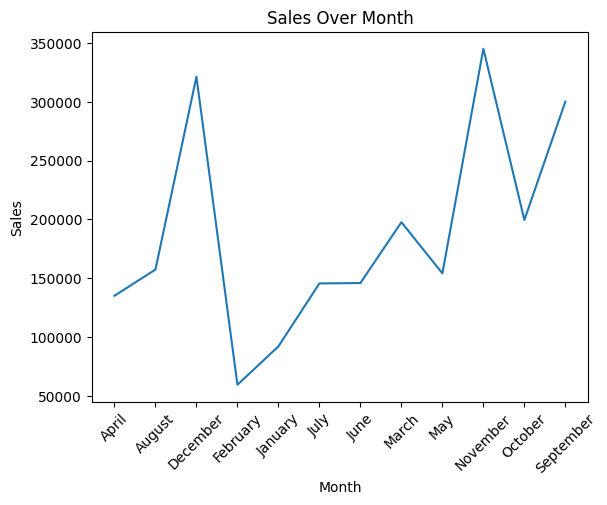

In [15]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

sns.lineplot(data=monthly_sales, x="Month", y="Sales")
plt.title("Sales Over Month")
plt.xticks(rotation=45)
plt.show()

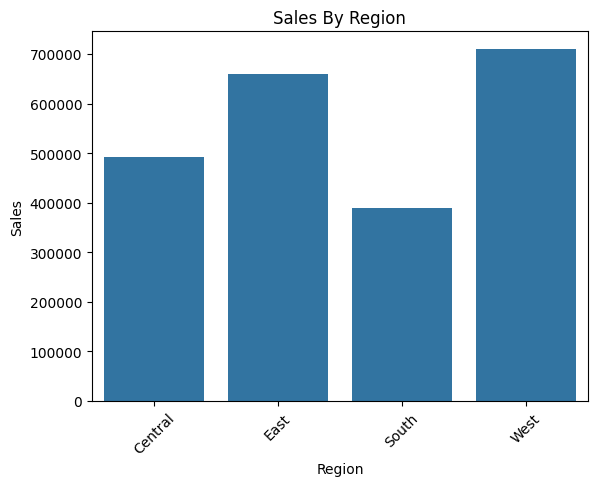

In [17]:
regional_sales = df.groupby("Region")["Sales"].sum().reset_index()

sns.barplot(data=regional_sales, x="Region", y="Sales")
plt.title("Sales By Region")
plt.xticks(rotation=45)
plt.show()

In [22]:
products = df.groupby('Product Name')['Sales'].sum().reset_index().sort_values(ascending=False).head(10)
top_products = df.sort_values(products, ascending=False)

sns.barplot(data=top_products,x="Product Name", y="Sales")
plt.title("Top 10 Products")
plt.show()

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'